2. Usando el modelo matemático obtenido del item anterior y la transformada de Laplace, obtenga la respuesta análitica del circuito cuando las condiciones iniciales son cero. Quiere decir la expresión para vc(t). A esta solución se llamará solución numérica usando Python (SA).

Salida en el tiempo:


⎛                                       1000⋅t     ⎛       2⎞  1000⋅t       2  ↪
⎝2⋅(sin(2000⋅π⋅t) - 2⋅π⋅cos(2000⋅π⋅t))⋅ℯ       + 3⋅⎝1 + 4⋅π ⎠⋅ℯ       - 12⋅π   ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                            ⎛       2⎞                         ↪
                                          2⋅⎝1 + 4⋅π ⎠                         ↪

↪          ⎞  -1000⋅t
↪ - 3 + 4⋅π⎠⋅ℯ       
↪ ───────────────────
↪                    
↪                    

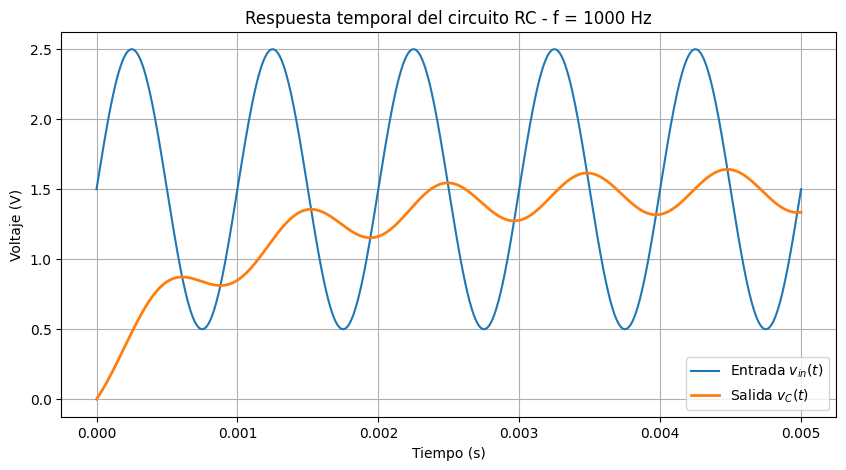

In [6]:
import sympy as sp
sp.init_printing()

import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Variables simbólicas
# =====================================
t, s = sp.symbols('t s', positive=True)

# Parámetros del circuito
R = sp.Integer(10000)            # 10 kΩ
C = sp.Rational(100, 10**9)      # 100 nF

Vp = sp.Integer(1)               # amplitud
Voff = sp.Rational(3,2)          # offset = 1.5 V

# =====================================
# Frecuencia (10, 159 o 1000 Hz)
# =====================================
f = 10
w = 2 * sp.pi * f

# =====================================
# Función de transferencia
# =====================================
H = 1 / (R*C*s + 1)

# Entrada en Laplace
Vin_s = Voff/s + (Vp*w)/(s**2 + w**2)

# Salida en Laplace
Vc_s = H * Vin_s

# Transformada inversa
vc_t = sp.inverse_laplace_transform(Vc_s, s, t)

print("Salida en el tiempo:")
display(sp.simplify(vc_t))

# =====================================
# Funciones numéricas
# =====================================
vc_func = sp.lambdify(t, vc_t, 'numpy')

# Entrada en el tiempo
vin_t = Voff + Vp * sp.sin(w*t)
vin_func = sp.lambdify(t, vin_t, 'numpy')

# =====================================
# Ajuste automático del tiempo
# =====================================
if f <= 20:
    t_final = 1
elif f <= 300:
    t_final = 0.05
else:
    # Mostrar ~5 períodos para altas frecuencias
    t_final = 5 / f

# Más resolución para frecuencias altas
t_vals = np.linspace(0, t_final, 5000)

# =====================================
# Evaluación numérica
# =====================================
vc_vals = vc_func(t_vals)
vin_vals = vin_func(t_vals)

# =====================================
# Gráfica
# =====================================
plt.figure(figsize=(10,5))

# Entrada
plt.plot(
    t_vals,
    vin_vals,
    label="Entrada $v_{in}(t)$"
)

# Salida
plt.plot(
    t_vals,
    vc_vals,
    label="Salida $v_C(t)$",
    linewidth=2
)

plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.title(f"Respuesta temporal del circuito RC - f = {f} Hz")

plt.legend()
plt.grid(True)

plt.show()

3.Realice un código en Python que coloque el modelo matemático y los resuelva. A esta solución se llamará solución numérica usando Python (SNP).

Ecuación diferencial del sistema:


Eq(C*R*Derivative(v_c(t), t) + v_c(t), Voff + Vp*sin(t*w))


Solución general:


Eq(v_c(t), -C*R*Vp*w*cos(t*w)/(C**2*R**2*w**2 + 1) + C1*exp(-t/(C*R)) + Voff + Vp*sin(t*w)/(C**2*R**2*w**2 + 1))


Solución con parámetros numéricos:


...

Eq(tau, 0.001)

Eq(phi, 1.41296513650674)

Eq(G, 0.15717672547759)


Respuesta del sistema en forma estándar:


sin(2000*pi*t - atan(2.0*pi))/sqrt(1 + 4.0*pi**2) + 1.5 - (-2.0*pi/(1 + 4.0*pi**2) + 1.5)*exp(-1000.0*t)

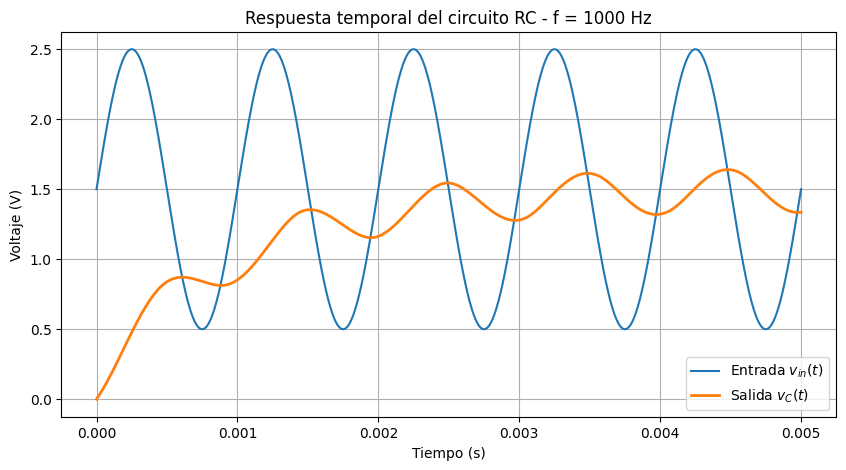

In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display

# =====================================
# Definición simbólica del problema
# =====================================
t = sp.symbols('t', real=True)
R, C, w = sp.symbols('R C w', positive=True)
Vp, Voff = sp.symbols('Vp Voff', real=True)

vc = sp.Function('v_c')(t)

# Ecuación diferencial
ode = sp.Eq(R*C*sp.diff(vc, t) + vc, Voff + Vp*sp.sin(w*t))

print("Ecuación diferencial del sistema:")
display(ode)

# Solución general
sol = sp.dsolve(ode, vc)

print("\nSolución general:")
display(sol)

# =====================================
# Sustitución de valores numéricos
# =====================================
R_val = 10e3          # 10 kΩ
C_val = 100e-9        # 100 nF
Vp_val = 1.0          # amplitud senoidal
Voff_val = 1.5        # offset DC

# =====================================
# Frecuencia de trabajo
# =====================================
f = 1000
# =====================================
w_val = 2 * sp.pi * f

sol_num = sol.subs({
    R: R_val,
    C: C_val,
    Vp: Vp_val,
    Voff: Voff_val,
    w: w_val
})

print("\nSolución con parámetros numéricos:")
display(sp.simplify(sol_num))

# =====================================
# Parámetros característicos
# =====================================
RC = R_val * C_val
tau = RC

phi = sp.atan(w_val * RC)
G = 1 / sp.sqrt(1 + (w_val * RC)**2)

print("\nParámetros del sistema:")
display(sp.Eq(sp.Symbol('tau'), tau))
display(sp.Eq(sp.Symbol('phi'), phi.evalf()))
display(sp.Eq(sp.Symbol('G'), G.evalf()))

# =====================================
# Expresión en forma estándar
# =====================================
vc_exp = (
    Voff_val
    + G * sp.sin(w_val*t - phi)
    + (-Voff_val + G*sp.sin(phi)) * sp.exp(-t/RC)
)

print("\nRespuesta del sistema en forma estándar:")
display(sp.simplify(vc_exp))

# =====================================
# Modelo numérico
# =====================================
def modelo(t, vc):
    vin = Voff_val + Vp_val * np.sin(float(w_val) * t)
    return (vin - vc) / RC

# =====================================
# Ajuste automático del tiempo
# =====================================
if f <= 200:
    t_final = 0.5
else:
    # Mostrar aproximadamente 5 períodos
    t_final = 5 / f

t_span = (0, t_final)

# Más puntos para frecuencias altas
t_eval = np.linspace(0, t_final, 5000)

# Condición inicial
vc0 = [0]

# Solución numérica
sol_numerica = solve_ivp(
    modelo,
    t_span,
    vc0,
    t_eval=t_eval
)

# Datos
t_vals = sol_numerica.t
vc_vals = sol_numerica.y[0]

vin_vals = (
    Voff_val
    + Vp_val * np.sin(float(w_val) * t_vals)
)

# =====================================
# Representación gráfica
# =====================================
plt.figure(figsize=(10,5))

plt.plot(
    t_vals,
    vin_vals,
    label="Entrada $v_{in}(t)$"
)

plt.plot(
    t_vals,
    vc_vals,
    label="Salida $v_C(t)$",
    linewidth=2
)

plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.title(f"Respuesta temporal del circuito RC - f = {f} Hz")

plt.legend()
plt.grid(True)

plt.show()